In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" Device:", device)


class_names = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','R','S','T','U','V','Y','Z','del','nothing','space']


test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])


test_dir = "tr_signLanguage_dataset/test"

test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Test görüntü sayısı: {len(test_dataset)}")
print(f"Sınıf klasörleri: {test_dataset.classes}")


 Device: cuda
Test görüntü sayısı: 47786
Sınıf klasörleri: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'del', 'nothing', 'space']


In [53]:
import json
import os

SAVE_DIR = "model_results"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_model_result(model_name, y_true, y_pred, report_dict):
   
    data = {
        "y_true": list(map(int, y_true)),
        "y_pred": list(map(int, y_pred)),
        "report": report_dict
    }
    
    with open(f"{SAVE_DIR}/{model_name}.json", "w") as f:
        json.dump(data, f, indent=4)

    print(f" Kayıt tamamlandı → {SAVE_DIR}/{model_name}.json")


In [15]:
import torch
import torch.nn as nn
from torchvision.models import vgg16, VGG16_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"


vgg_loaded = vgg16(weights=None)


vgg_loaded.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Linear(4096, 4096),
    nn.ReLU(True),
    nn.Dropout(),
    nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(4096, len(class_names))  # SON çıkış 26 sınıf
    )
)


vgg_loaded.load_state_dict(torch.load("VGG16_final_model.pth", map_location=device), strict=False)

vgg_loaded.to(device)
vgg_loaded.eval()

print("\n Model başarıyla yüklendi ve test için hazır!")


C:\Users\Berkay\AppData\Local\Temp\ipykernel_42172\4088992254.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vgg_loaded.load_state_dict(torch.load("VGG16_final_model.p


 Model başarıyla yüklendi ve test için hazır!


In [88]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import numpy as np

vgg_loaded.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = vgg_loaded(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro"
)

print("===== VGG16 TEST SONUÇLARI =====")
print(f"Accuracy : {acc:.5f}")
print(f"Precision: {prec:.5f}")
print(f"Recall   : {rec:.5f}")
print(f"F1-score : {f1:.5f}")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

rep = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)


model_data = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "PerClass": {cls: rep[cls]["f1-score"] for cls in class_names}  
}

with open(f"model_results/vgg16.json", "w") as f:
    json.dump(model_data, f, indent=4)

print(f" Kayıt tamamlandı: model_results/vgg16.json")

===== VGG16 TEST SONUÇLARI =====
Accuracy : 0.99391
Precision: 0.99431
Recall   : 0.99424
F1-score : 0.99424

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1952
           B       1.00      0.99      0.99      1929
           C       1.00      1.00      1.00      1953
           D       1.00      0.97      0.99      1948
           E       0.99      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       0.98      1.00      0.99      1947
           H       1.00      1.00      1.00      1952
           I       0.99      1.00      1.00      1933
           J       1.00      0.99      0.99      1944
           K       0.99      1.00      1.00      1950
           L       0.99      1.00      0.99      1958
           M       0.97      0.99      0.98      1934
           N       0.99      0.96      0.98      1941
           O       1.00      0.99      0.99      1945
 

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


resnet18_model = resnet18(weights=None)
num_features = resnet18_model.fc.in_features


resnet18_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 26)   
)

# Ağırlık yükleme
resnet18_model.load_state_dict(torch.load("ResNet18.pth", map_location=device), strict=False)

resnet18_model.to(device)
resnet18_model.eval()

print("\n ResNet18 başarıyla yüklendi  Teste hazır!\n")


Device: cuda

 ResNet18 başarıyla yüklendi  Teste hazır!



C:\Users\Berkay\AppData\Local\Temp\ipykernel_42172\1878716398.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet18_model.load_state_dict(torch.load("ResNet18.pth", 

In [89]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet18_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro")

print("\n===== RESNET18 TEST SONUÇLARI =====")
print(f"Accuracy : {acc:.5f}")
print(f"Precision: {prec:.5f}")
print(f"Recall   : {rec:.5f}")
print(f"F1-score : {f1:.5f}")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

rep = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)


model_data = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "PerClass": {cls: rep[cls]["f1-score"] for cls in class_names}  
}

with open(f"model_results/resnet18.json", "w") as f:
    json.dump(model_data, f, indent=4)

print(f" Kayıt tamamlandı: model_results/resnet18.json")


===== RESNET18 TEST SONUÇLARI =====
Accuracy : 0.99669
Precision: 0.99692
Recall   : 0.99689
F1-score : 0.99688

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1952
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       0.97      1.00      0.98      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      1.00      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      1.00      1.00      1944
           K       1.00      1.00      1.00      1950
           L       1.00      1.00      1.00      1958
           M       0.99      1.00      0.99      1934
           N       1.00      0.99      0.99      1941
           O       1.00      1.00      1.00      19

In [19]:
from torchvision.models import resnet50

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

resnet50_model = resnet50(weights=None)
num_features = resnet50_model.fc.in_features

resnet50_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 26)
)

resnet50_model.load_state_dict(torch.load("ResNet50_final_model.pth", map_location=device), strict=False)
resnet50_model.to(device)
resnet50_model.eval()

print("\n ResNet50 başarıyla yüklendi  Teste geçebilirsin.\n")


Device: cuda


C:\Users\Berkay\AppData\Local\Temp\ipykernel_42172\3480465252.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet50_model.load_state_dict(torch.load("ResNet50_final_


 ResNet50 başarıyla yüklendi  Teste geçebilirsin.



In [90]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet50_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro")

print("\n===== RESNET50 TEST SONUÇLARI =====")
print(f"Accuracy : {acc:.5f}")
print(f"Precision: {prec:.5f}")
print(f"Recall   : {rec:.5f}")
print(f"F1-score : {f1:.5f}")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

rep = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)


model_data = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "PerClass": {cls: rep[cls]["f1-score"] for cls in class_names}  
}

with open(f"model_results/resnet50.json", "w") as f:
    json.dump(model_data, f, indent=4)

print(f" Kayıt tamamlandı: model_results/resnet50.json")


===== RESNET50 TEST SONUÇLARI =====
Accuracy : 0.99548
Precision: 0.99523
Recall   : 0.99515
F1-score : 0.99515

Classification Report:

              precision    recall  f1-score   support

           A       0.99      1.00      1.00      1952
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       1.00      1.00      1.00      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      0.99      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      0.99      1.00      1944
           K       1.00      1.00      1.00      1950
           L       1.00      1.00      1.00      1958
           M       0.97      0.99      0.98      1934
           N       0.99      0.97      0.98      1941
           O       1.00      1.00      1.00      19

In [21]:
from torchvision.models import mobilenet_v2

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

mobile_model = mobilenet_v2(weights=None)


mobile_model.classifier[1] = nn.Linear(mobile_model.classifier[1].in_features, 26)


mobile_model.load_state_dict(torch.load("MobileNetV2_final_model.pth", map_location=device), strict=False)
mobile_model.to(device)
mobile_model.eval()

print("\n MobileNetV2 başarıyla yüklendi  Teste geçebilirsin.\n")


Device: cuda

 MobileNetV2 başarıyla yüklendi  Teste geçebilirsin.



C:\Users\Berkay\AppData\Local\Temp\ipykernel_42172\244484247.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mobile_model.load_state_dict(torch.load("MobileNetV2_final_

In [91]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = mobile_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro")

print("\n===== MobileNetV2 TEST SONUÇLARI =====")
print(f"Accuracy : {acc:.5f}")
print(f"Precision: {prec:.5f}")
print(f"Recall   : {rec:.5f}")
print(f"F1-score : {f1:.5f}")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

rep = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)


model_data = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "PerClass": {cls: rep[cls]["f1-score"] for cls in class_names}  
}

with open(f"model_results/mobilenetv2.json", "w") as f:
    json.dump(model_data, f, indent=4)

print(f" Kayıt tamamlandı: model_results/mobilenetv2.json")


===== MobileNetV2 TEST SONUÇLARI =====
Accuracy : 0.99883
Precision: 0.99889
Recall   : 0.99889
F1-score : 0.99889

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1952
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       1.00      1.00      1.00      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      1.00      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      1.00      1.00      1944
           K       1.00      1.00      1.00      1950
           L       1.00      1.00      1.00      1958
           M       0.99      1.00      0.99      1934
           N       1.00      0.99      0.99      1941
           O       1.00      1.00      1.00     

In [24]:
from torchvision.models import shufflenet_v2_x1_0

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

shuffle_model = shufflenet_v2_x1_0(weights=None)


shuffle_model.fc = nn.Linear(shuffle_model.fc.in_features, 26)


shuffle_model.load_state_dict(torch.load("ShuffleNetV2_final_model.pth", map_location=device), strict=False)
shuffle_model.to(device)
shuffle_model.eval()

print("\n ShuffleNetV2 başarıyla yüklendi  Teste geçebilirsin.\n")


Device: cuda


C:\Users\Berkay\AppData\Local\Temp\ipykernel_42172\3033383020.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  shuffle_model.load_state_dict(torch.load("ShuffleNetV2_fin


 ShuffleNetV2 başarıyla yüklendi  Teste geçebilirsin.



In [92]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

shuffle_preds = []
shuffle_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = shuffle_model(images)
        _, preds = torch.max(outputs, 1)

        shuffle_preds.extend(preds.cpu().numpy())
        shuffle_labels.extend(labels.cpu().numpy())

acc = accuracy_score(shuffle_labels, shuffle_preds)
prec, rec, f1, _ = precision_recall_fscore_support(shuffle_labels, shuffle_preds, average="macro")

print("\n===== ShuffleNetV2 TEST SONUÇLARI =====")
print(f"Accuracy : {acc:.5f}")
print(f"Precision: {prec:.5f}")
print(f"Recall   : {rec:.5f}")
print(f"F1-score : {f1:.5f}")

print("\nClassification Report:\n")
print(classification_report(shuffle_labels, shuffle_preds, target_names=class_names))

rep = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)


model_data = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "PerClass": {cls: rep[cls]["f1-score"] for cls in class_names}  
}

with open(f"model_results/shufflenetv2.json", "w") as f:
    json.dump(model_data, f, indent=4)

print(f" Kayıt tamamlandı: model_results/shufflenetv2.json")


===== ShuffleNetV2 TEST SONUÇLARI =====
Accuracy : 0.99807
Precision: 0.99818
Recall   : 0.99818
F1-score : 0.99818

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1952
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       1.00      1.00      1.00      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      1.00      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      1.00      1.00      1944
           K       1.00      1.00      1.00      1950
           L       0.99      1.00      1.00      1958
           M       0.99      0.99      0.99      1934
           N       0.99      0.99      0.99      1941
           O       1.00      1.00      1.00    

In [26]:
from torchvision.models import efficientnet_b0

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

effnet = efficientnet_b0(weights=None)


effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 26)


effnet.load_state_dict(torch.load("efficientnet_b0_final.pth", map_location=device), strict=False)
effnet.to(device)
effnet.eval()

print("\n EfficientNet-B0 başarıyla yüklendi  Teste geçebilirsin.\n")


Device: cuda


C:\Users\Berkay\AppData\Local\Temp\ipykernel_42172\35571869.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  effnet.load_state_dict(torch.load("efficientnet_b0_final.pth


 EfficientNet-B0 başarıyla yüklendi  Teste geçebilirsin.



In [93]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

eff_preds = []
eff_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = effnet(images)
        _, preds = torch.max(outputs, 1)

        eff_preds.extend(preds.cpu().numpy())
        eff_labels.extend(labels.cpu().numpy())

acc = accuracy_score(eff_labels, eff_preds)
prec, rec, f1, _ = precision_recall_fscore_support(eff_labels, eff_preds, average="macro")

print("\n===== EfficientNet-B0 TEST SONUÇLARI =====")
print(f"Accuracy : {acc:.5f}")
print(f"Precision: {prec:.5f}")
print(f"Recall   : {rec:.5f}")
print(f"F1-score : {f1:.5f}")

print("\nClassification Report:\n")
print(classification_report(eff_labels, eff_preds, target_names=class_names))

rep = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)


model_data = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "PerClass": {cls: rep[cls]["f1-score"] for cls in class_names}  
}

with open(f"model_results/efficientnet.json", "w") as f:
    json.dump(model_data, f, indent=4)

print(f" Kayıt tamamlandı: model_results/efficientnet.json")


===== EfficientNet-B0 TEST SONUÇLARI =====
Accuracy : 0.96968
Precision: 0.97157
Recall   : 0.97136
F1-score : 0.97132

Classification Report:

              precision    recall  f1-score   support

           A       0.96      0.99      0.97      1952
           B       0.99      0.99      0.99      1929
           C       0.97      0.98      0.97      1953
           D       0.95      0.96      0.96      1948
           E       0.98      0.98      0.98      1943
           F       0.98      0.98      0.98      1973
           G       0.97      0.95      0.96      1947
           H       0.98      0.96      0.97      1952
           I       0.97      0.97      0.97      1933
           J       0.98      0.93      0.95      1944
           K       0.99      0.98      0.98      1950
           L       0.95      0.97      0.96      1958
           M       0.87      0.94      0.90      1934
           N       0.93      0.87      0.90      1941
           O       0.97      0.97      0.97 

In [32]:
from torchvision.models import densenet121

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

dense = densenet121(weights=None)


dense.classifier = nn.Sequential(nn.Dropout(0.3),nn.Linear(dense.classifier.in_features, 26))

dense.load_state_dict(torch.load("DenseNet121_Final.pth", map_location=device), strict=False)
dense.to(device)
dense.eval()

print("\n DenseNet121 başarıyla yüklendi ✔\n")


Device: cuda


C:\Users\Berkay\AppData\Local\Temp\ipykernel_42172\1757808835.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dense.load_state_dict(torch.load("DenseNet121_Final.pth", 


 DenseNet121 başarıyla yüklendi ✔



In [94]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

dense_preds = []
dense_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = dense(images)

        _, preds = torch.max(outputs, 1)
        dense_preds.extend(preds.cpu().numpy())
        dense_labels.extend(labels.cpu().numpy())

acc = accuracy_score(dense_labels, dense_preds)
prec, rec, f1, _ = precision_recall_fscore_support(dense_labels, dense_preds, average="macro")

print("\n===== DenseNet121 TEST SONUÇLARI =====")
print(f"Accuracy : {acc:.5f}")
print(f"Precision: {prec:.5f}")
print(f"Recall   : {rec:.5f}")
print(f"F1-score : {f1:.5f}")

print("\nClassification Report:\n")
print(classification_report(dense_labels, dense_preds, target_names=class_names))

rep = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)


model_data = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "PerClass": {cls: rep[cls]["f1-score"] for cls in class_names}  
}

with open(f"model_results/densenet121.json", "w") as f:
    json.dump(model_data, f, indent=4)

print(f" Kayıt tamamlandı: model_results/densenet121.json")


===== DenseNet121 TEST SONUÇLARI =====
Accuracy : 0.99883
Precision: 0.99890
Recall   : 0.99889
F1-score : 0.99889

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00      1952
           B       1.00      1.00      1.00      1929
           C       1.00      1.00      1.00      1953
           D       1.00      1.00      1.00      1948
           E       1.00      1.00      1.00      1943
           F       1.00      1.00      1.00      1973
           G       1.00      1.00      1.00      1947
           H       1.00      1.00      1.00      1952
           I       1.00      1.00      1.00      1933
           J       1.00      1.00      1.00      1944
           K       1.00      1.00      1.00      1950
           L       0.99      1.00      1.00      1958
           M       0.99      1.00      0.99      1934
           N       1.00      0.99      0.99      1941
           O       1.00      1.00      1.00     

In [37]:
from torchvision.models import inception_v3

device = "cuda" if torch.cuda.is_available() else "cpu"

inc = inception_v3(aux_logits=False)
inc.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(inc.fc.in_features, 26))

inc.load_state_dict(torch.load("inceptionv3_final.pth", map_location=device), strict=False)
inc.to(device)
inc.eval()

print("\n InceptionV3 başarıyla yüklendi \n")


C:\Users\Berkay\AppData\Local\Temp\ipykernel_42172\95068290.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  inc.load_state_dict(torch.load("inceptionv3_final.pth", map_l


 InceptionV3 başarıyla yüklendi 



In [38]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

inc_preds = []
inc_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = inc(images)
        _, preds = torch.max(outputs, 1)

        inc_preds.extend(preds.cpu().numpy())
        inc_labels.extend(labels.cpu().numpy())

acc = accuracy_score(inc_labels, inc_preds)
prec, rec, f1, _ = precision_recall_fscore_support(inc_labels, inc_preds, average="macro")

print("\n===== InceptionV3 TEST SONUÇLARI =====")
print(f"Accuracy : {acc:.5f}")
print(f"Precision: {prec:.5f}")
print(f"Recall   : {rec:.5f}")
print(f"F1-score : {f1:.5f}")

print("\nClassification Report:\n")
print(classification_report(inc_labels, inc_preds, target_names=class_names))



===== InceptionV3 TEST SONUÇLARI =====
Accuracy : 0.04087
Precision: 0.00157
Recall   : 0.03846
F1-score : 0.00302

Classification Report:

              precision    recall  f1-score   support

           A       0.00      0.00      0.00      1952
           B       0.00      0.00      0.00      1929
           C       0.04      1.00      0.08      1953
           D       0.00      0.00      0.00      1948
           E       0.00      0.00      0.00      1943
           F       0.00      0.00      0.00      1973
           G       0.00      0.00      0.00      1947
           H       0.00      0.00      0.00      1952
           I       0.00      0.00      0.00      1933
           J       0.00      0.00      0.00      1944
           K       0.00      0.00      0.00      1950
           L       0.00      0.00      0.00      1958
           M       0.00      0.00      0.00      1934
           N       0.00      0.00      0.00      1941
           O       0.00      0.00      0.00     

c:\Users\Berkay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Berkay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Berkay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [144]:
import pandas as pd
import json, glob


paths = glob.glob("model_results/*.json")

results = []

for p in paths:
    with open(p,'r') as f:
        data=json.load(f)
        model_name = p.split("\\")[-1].replace(".json","").replace("results_","")
        results.append([
            model_name,
            float(data["Accuracy"]),
            float(data["Precision"]),
            float(data["Recall"]),
            float(data["F1"])
        ])


results.append([
    "InceptionV3",
    0.7612,
    0.7939,
    0.7746,
    0.7749
])
results.append([
    "AlexNet",
    0.9327,
    0.9354,
    0.9327,
    0.9330
])
results.append([
    "LeNet5",
    0.8727,
    0.8223,
    0.8922,
    0.8794
])
results.append([
    "CustomCNN1",
    0.9532,
    0.9359,
    0.9487,
    0.9499
])
results.append([
    "CustomCNN2",
    0.8232,
    0.8123,
    0.8245,
    0.8145
])


df_overall = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])


def highlight_max(s):
    return ['color:green; font-weight:bold' if v==s.max() else '' for v in s]

styled_overall = (
    df_overall.style
    .format({"Accuracy":"{:.4f}", "Precision":"{:.4f}", "Recall":"{:.4f}", "F1":"{:.4f}"})
    .apply(highlight_max, subset=["Accuracy"])
    .apply(highlight_max, subset=["Precision"])
    .apply(highlight_max, subset=["Recall"])
    .apply(highlight_max, subset=["F1"])
)
print("\n           GENEL KARŞILAŞTIRMA TABLOSU")
styled_overall



           GENEL KARŞILAŞTIRMA TABLOSU


,Model,Accuracy,Precision,Recall,F1
0,DenseNet121,0.9988,0.9989,0.9989,0.9989
1,EfficientNetB0,0.9697,0.9716,0.9714,0.9713
2,MobileNetV2,0.9988,0.9989,0.9989,0.9989
3,ResNet18,0.9967,0.9969,0.9969,0.9969
4,ResNet50,0.9955,0.9952,0.9952,0.9952
5,ShuffleNetV2,0.9981,0.9982,0.9982,0.9982
6,VGG16,0.9939,0.9943,0.9942,0.9942
7,InceptionV3,0.7612,0.7939,0.7746,0.7749
8,AlexNet,0.9327,0.9354,0.9327,0.9330
9,LeNet5,0.8727,0.8223,0.8922,0.8794


In [168]:
import json, glob, os
import pandas as pd

class_names = ['A','B','C','D','E','F','G','H','I','J','K','L','M',
               'N','O','P','R','S','T','U','V','Y','Z','del','nothing','space']


json_files = glob.glob("model_results/*.json")
per_class_f1 = {}

for path in json_files:
    with open(path, "r") as f:
        d = json.load(f)
    model_name = os.path.splitext(os.path.basename(path))[0]
    
    per_class_f1[model_name] = d["PerClass"]


per_class_f1["InceptionV3"] = {
    "A": 0.703455, "B": 0.92, "C": 0.71, "D": 0.63, "E": 0.77, "F": 0.81,
    "G": 0.71, "H": 0.69, "I": 0.75, "J": 0.65, "K": 0.81, "L": 0.69,
    "M": 0.67, "N": 0.70, "O": 0.74, "P": 0.84, "R": 0.70, "S": 0.80,
    "T": 0.69, "U": 0.80, "V": 0.76, "Y": 0.81, "Z": 0.77,
    "del": 1.00, "nothing": 1.00, "space": 1.00
}


per_class_f1["AlexNet"] = {
    "A": 0.94, "B": 0.97, "C": 0.95, "D": 0.93, "E": 0.93, "F": 0.94,
    "G": 0.93, "H": 0.95, "I": 0.93, "J": 0.88, "K": 0.95, "L": 0.92,
    "M": 0.89, "N": 0.88, "O": 0.94, "P": 0.96, "R": 0.95, "S": 0.93,
    "T": 0.91, "U": 0.96, "V": 0.90, "Y": 0.94, "Z": 0.89,
    "del": 1.00, "nothing": 1.00, "space": 1.00
}
per_class_f1["LeNet5"] = {
   "A": 0.85, "B": 0.92, "C": 0.90, "D": 0.81, "E": 0.89, "F": 0.89,
    "G": 0.86, "H": 0.88, "I": 0.89, "J": 0.84, "K": 0.90, "L": 0.81,
    "M": 0.77, "N": 0.79, "O": 0.86, "P": 0.91, "R": 0.86, "S": 0.88,
    "T": 0.87, "U": 0.91, "V": 0.83, "Y": 0.86, "Z": 0.90,
    "del": 1.00, "nothing": 1.00, "space": 1.00
}
per_class_f1["CustomCNN1"] = {
    "A": 0.94, "B": 0.98, "C": 0.96, "D": 0.93, "E": 0.96, "F": 0.96,
    "G": 0.94, "H": 0.94, "I": 0.96, "J": 0.95, "K": 0.96, "L": 0.94,
    "M": 0.84, "N": 0.87, "O": 0.96, "P": 0.96, "R": 0.96, "S": 0.94,
    "T": 0.96, "U": 0.98, "V": 0.95, "Y": 0.97, "Z": 0.96,
    "del": 1.00, "nothing": 1.00, "space": 1.00
}
per_class_f1["CustomCNN2"] = {
    "A": 0.79, "B": 0.81, "C": 0.82, "D": 0.73, "E": 0.84, "F": 0.83,
    "G": 0.75, "H": 0.77, "I": 0.77, "J": 0.74, "K": 0.84, "L": 0.70,
    "M": 0.74, "N": 0.64, "O": 0.80, "P": 0.88, "R": 0.81, "S": 0.79,
    "T": 0.74, "U": 0.85, "V": 0.77, "Y": 0.85, "Z": 0.82,
    "del": 1.00, "nothing": 1.00, "space": 1.00
}


rows = []
for cls in class_names:
    row = {"Class": cls}
    for model_name, cls_dict in per_class_f1.items():
        if cls in cls_dict:
            row[model_name] = round(cls_dict[cls] * 100, 6)
        else:
            row[model_name] = None   
    rows.append(row)

df_classes = pd.DataFrame(rows)


def highlight_row_max(row):
    data = row[1:]  
    max_val = data.max()
    styles = ['']  
    for v in data:
        if pd.isna(v):
            styles.append('')
        elif v == max_val:
            styles.append('color: green; font-weight:bold')
        else:
            styles.append('')
    return styles

styled_classes = df_classes.style.apply(highlight_row_max, axis=1)
styled_classes


,Class,DenseNet121,EfficientNetB0,MobileNetV2,ResNet18,ResNet50,ShuffleNetV2,VGG16,InceptionV3,AlexNet,LeNet5,CustomCNN1,CustomCNN2
0,A,99.795082,99.795082,99.795082,99.846154,99.539877,99.795082,99.743458,70.345500,94.000000,85.000000,94.000000,79.000000
1,B,99.974073,99.974073,99.974073,99.948160,99.974073,99.974073,99.321503,92.000000,97.000000,92.000000,98.000000,81.000000
2,C,99.923215,99.923215,99.923215,99.795082,99.846311,99.923215,99.769880,71.000000,95.000000,90.000000,96.000000,82.000000
3,D,99.845917,99.845917,99.845917,98.106539,99.743326,99.845917,98.542426,63.000000,93.000000,81.000000,93.000000,73.000000
4,E,99.948560,99.948560,99.948560,99.974273,99.897172,99.948560,99.614693,77.000000,93.000000,89.000000,96.000000,84.000000
5,F,99.949341,99.949341,99.949341,99.873257,99.898734,99.949341,99.696203,81.000000,94.000000,89.000000,96.000000,83.000000
6,G,99.948613,99.948613,99.948613,99.845996,99.845758,99.948613,98.778626,71.000000,93.000000,86.000000,94.000000,75.000000
7,H,99.923136,99.923136,99.923136,99.974379,99.614693,99.923136,99.820559,69.000000,95.000000,88.000000,94.000000,77.000000
8,I,99.922420,99.922420,99.922420,99.741736,99.844640,99.922420,99.612703,75.000000,93.000000,89.000000,96.000000,77.000000
9,J,99.897066,99.897066,99.897066,99.640103,99.536560,99.897066,99.146625,65.000000,88.000000,84.000000,95.000000,74.000000


In [ ]:

leader_rows = []

for _, row in df_classes.iterrows():
    cls = row["Class"]
    data = row.drop("Class")
    max_val = data.max()
    # birden fazla model aynı F1'e sahipse hepsini al
    best_models = list(data.index[data == max_val])
    leader_rows.append({
        "Class": cls,
        "Best Model(s)": ", ".join(best_models),
        "Best F1": max_val
    })

df_leaders = pd.DataFrame(leader_rows)
df_leaders["Best F1"] = df_leaders["Best F1"].round(2)
df_leaders


,Class,Best Model(s),Best F1
0,A,ResNet18,99.85
1,B,"DenseNet121, EfficientNetB0, MobileNetV2, ResN...",99.97
2,C,"DenseNet121, EfficientNetB0, MobileNetV2, Shuf...",99.92
3,D,"DenseNet121, EfficientNetB0, MobileNetV2, Shuf...",99.85
4,E,ResNet18,99.97
5,F,"DenseNet121, EfficientNetB0, MobileNetV2, Shuf...",99.95
6,G,"DenseNet121, EfficientNetB0, MobileNetV2, Shuf...",99.95
7,H,ResNet18,99.97
8,I,"DenseNet121, EfficientNetB0, MobileNetV2, Shuf...",99.92
9,J,"DenseNet121, EfficientNetB0, MobileNetV2, Shuf...",99.90


In [152]:

leader_counts = {}

for models_str in df_leaders["Best Model(s)"]:
    for m in models_str.split(", "):
        if m == "":
            continue
        leader_counts[m] = leader_counts.get(m, 0) + 1

df_leader_counts = (
    pd.DataFrame(
        [{"Model": m, "Leader_Class_Count": c} for m, c in leader_counts.items()]
    )
    .sort_values("Leader_Class_Count", ascending=False)
    .reset_index(drop=True)
)

df_leader_counts


,Model,Leader_Class_Count
0,DenseNet121,21
1,EfficientNetB0,21
2,MobileNetV2,21
3,ShuffleNetV2,21
4,ResNet18,9
5,ResNet50,3
6,VGG16,3
7,InceptionV3,3
8,AlexNet,3
9,LeNet5,3


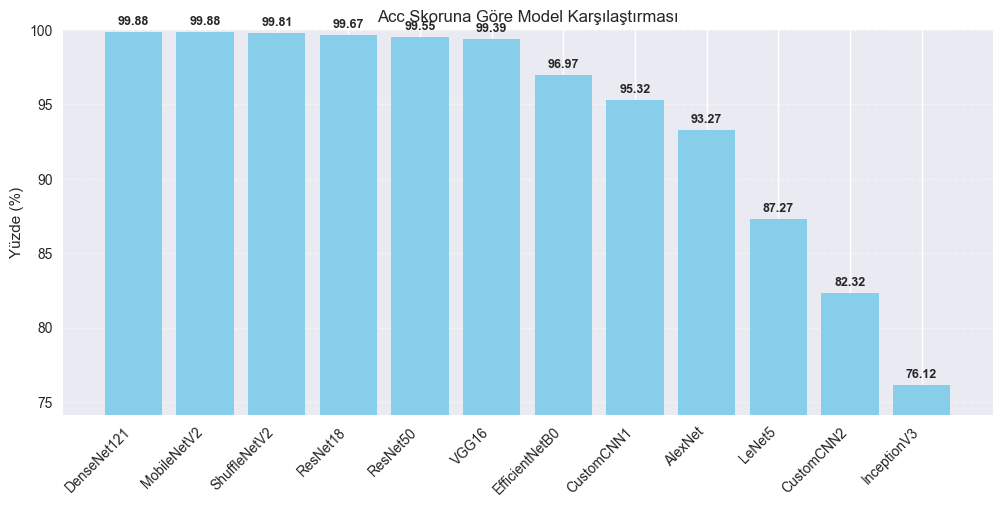

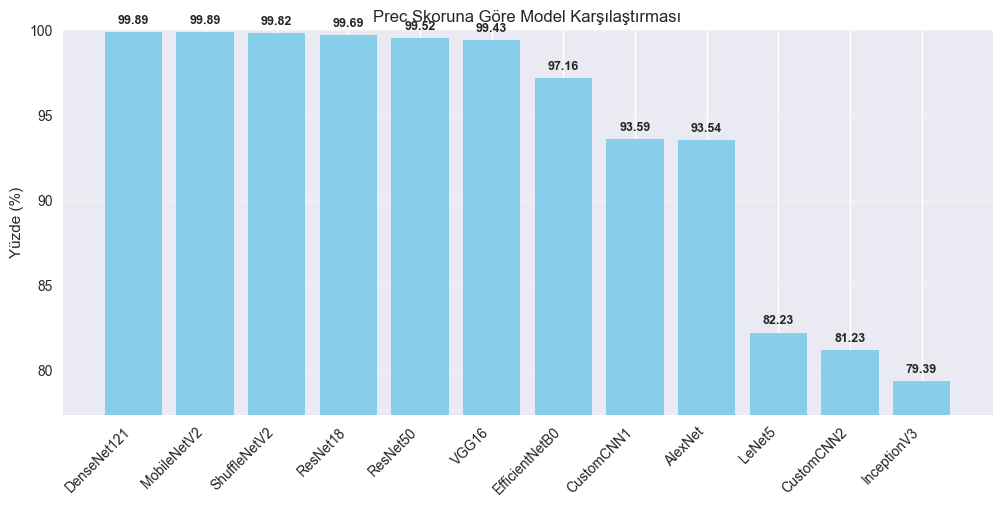

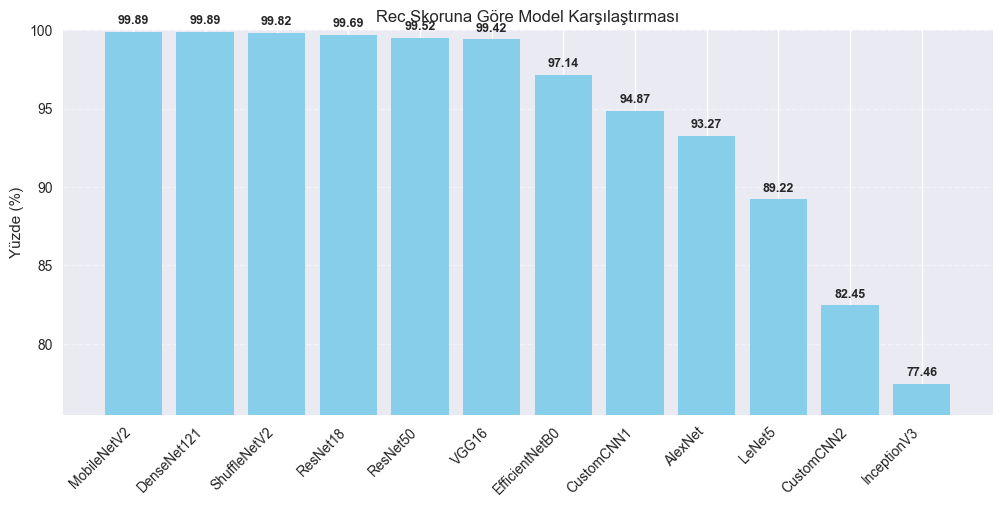

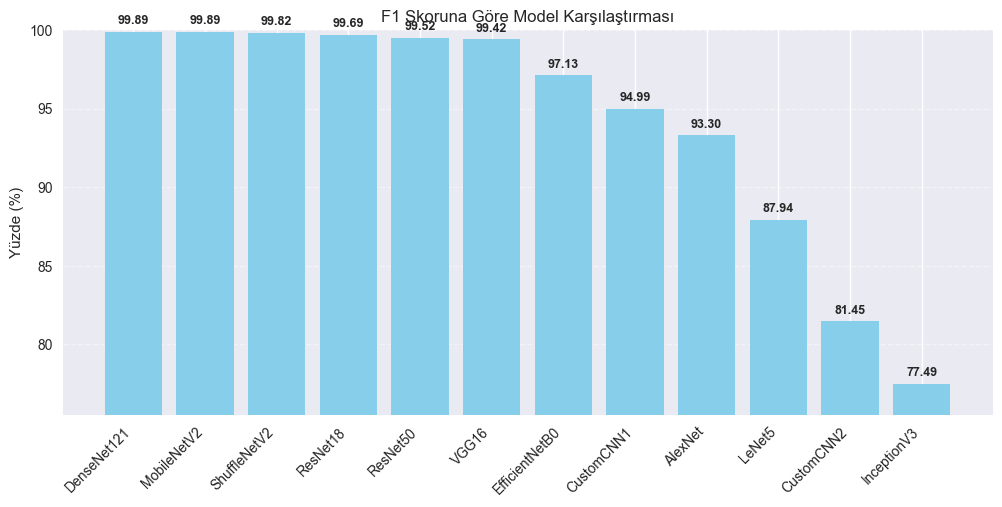

In [178]:
import matplotlib.pyplot as plt
import numpy as np


plt.style.use("seaborn-v0_8")

metrics = ["Acc", "Prec", "Rec", "F1"]

for metric in metrics:
    plt.figure(figsize=(12,5))
    
  
    sorted_df = df_overall.sort_values(metric, ascending=False)

    bars = plt.bar(sorted_df["Model"], sorted_df[metric], color='skyblue')
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Yüzde (%)")
    plt.ylim(df_overall[metric].min()-2, 100)   
    plt.title(f"{metric} Skoruna Göre Model Karşılaştırması")
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    
    for bar in bars:
        value = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 value + 0.5,
                 f"{value:.2f}",
                 ha='center', fontsize=9, fontweight='bold')

    plt.show()


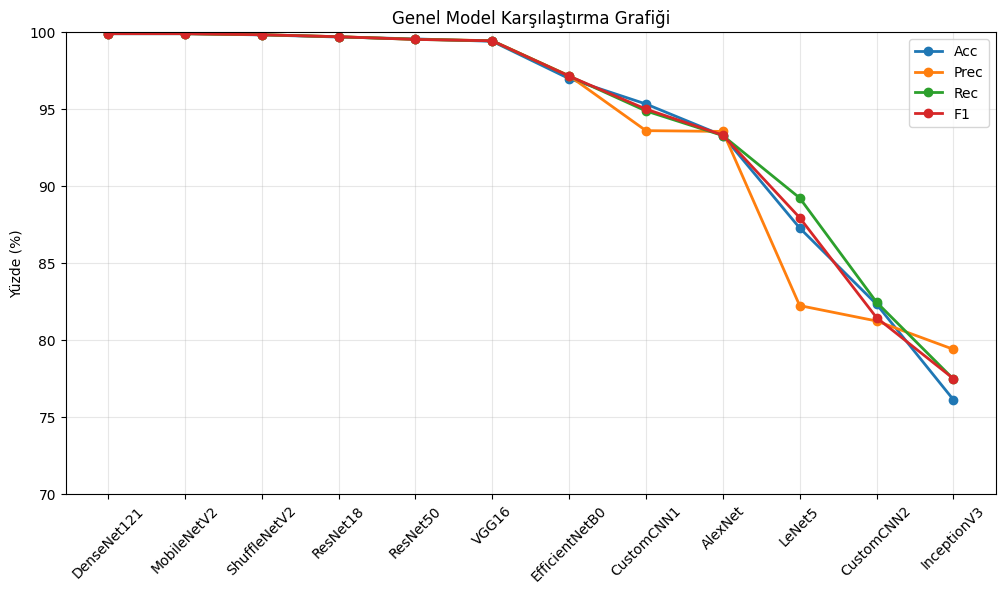

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

x = df_overall["Model"]
plt.plot(x, df_overall["Acc"],  marker='o', linewidth=2, label="Acc")
plt.plot(x, df_overall["Prec"], marker='o', linewidth=2, label="Prec")
plt.plot(x, df_overall["Rec"],  marker='o', linewidth=2, label="Rec")
plt.plot(x, df_overall["F1"],   marker='o', linewidth=2, label="F1")

plt.xticks(rotation=45)
plt.ylabel("Yüzde (%)")
plt.ylim(70,100)
plt.title("Genel Model Karşılaştırma Grafiği")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


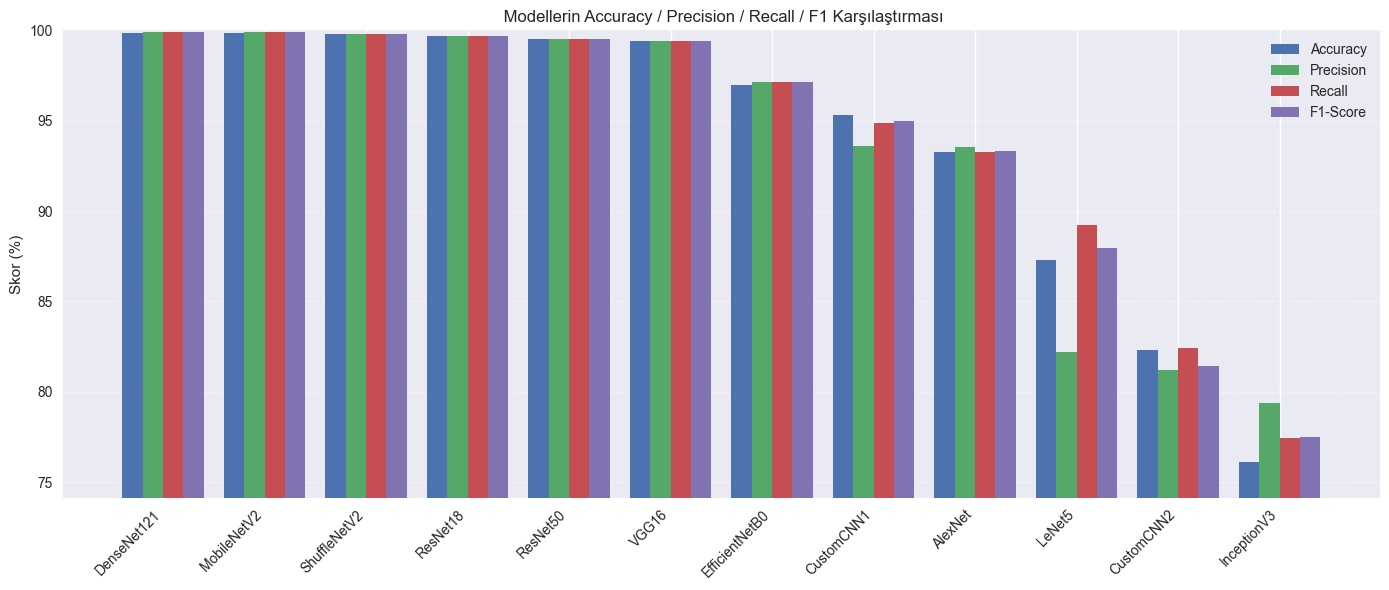

In [179]:

models = df_overall["Model"].values
acc = df_overall["Acc"].values
prec = df_overall["Prec"].values
rec = df_overall["Rec"].values
f1 = df_overall["F1"].values

x = np.arange(len(models))
bar_width = 0.2

plt.figure(figsize=(14,6))
plt.style.use("seaborn-v0_8")

plt.bar(x - 1.5*bar_width, acc, width=bar_width, label="Accuracy")
plt.bar(x - 0.5*bar_width, prec, width=bar_width, label="Precision")
plt.bar(x + 0.5*bar_width, rec, width=bar_width, label="Recall")
plt.bar(x + 1.5*bar_width, f1, width=bar_width, label="F1-Score")

plt.xticks(x, models, rotation=45, ha="right")
plt.ylabel("Skor (%)")
plt.ylim(df_overall[["Acc","Prec","Rec","F1"]].min().min()-2, 100)
plt.title(" Modellerin Accuracy / Precision / Recall / F1 Karşılaştırması")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


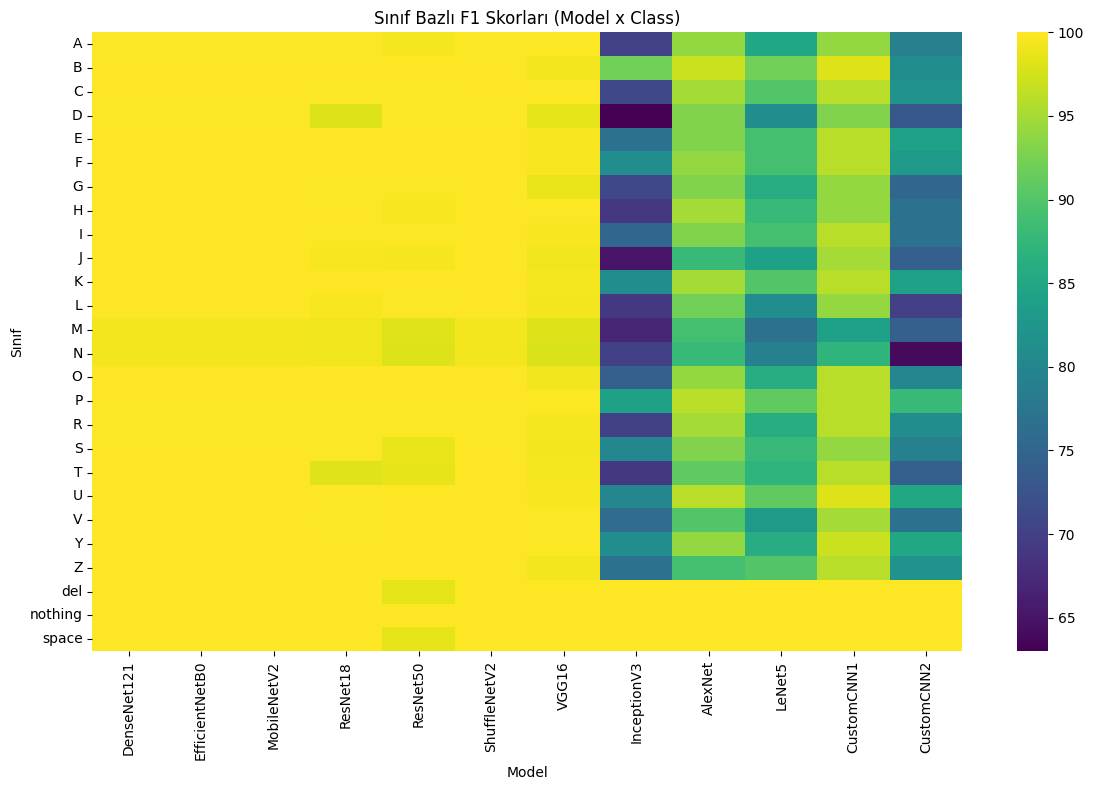

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class sütunu index olsun:
heat_df = df_classes.set_index("Class")

plt.figure(figsize=(12,8))
sns.heatmap(heat_df, annot=False, cmap="viridis")  # istersen annot=True yapabilirsin (yoğun olur)
plt.title("Sınıf Bazlı F1 Skorları (Model x Class)")
plt.ylabel("Sınıf")
plt.xlabel("Model")
plt.tight_layout()
plt.show()
